<a href="https://colab.research.google.com/github/Andresfms22/TelecomX2/blob/DEV/TelecomX2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

df = pd.read_csv("datos_tratados.csv")
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'datos_tratados.csv'

In [2]:
from google.colab import files
uploaded = files.upload()

Saving datos_tratados.csv to datos_tratados.csv


In [3]:
import pandas as pd
df = pd.read_csv("datos_tratados.csv")
df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

df.head()
df.shape, df.dtypes

((7256, 21),
 customerID           object
 Churn                object
 gender               object
 SeniorCitizen         int64
 Partner              object
 Dependents           object
 tenure                int64
 PhoneService         object
 MultipleLines        object
 InternetService      object
 OnlineSecurity       object
 OnlineBackup         object
 DeviceProtection     object
 TechSupport          object
 StreamingTV          object
 StreamingMovies      object
 Contract             object
 PaperlessBilling     object
 PaymentMethod        object
 Charges.Monthly     float64
 Charges.Total       float64
 dtype: object)

In [5]:
df.isna().sum()
df["Churn"].value_counts(normalize=True)

,proportion
Churn,
No,0.734215
Yes,0.265785


In [6]:
# Convertir columnas numéricas
df["Charges.Monthly"] = pd.to_numeric(df["Charges.Monthly"], errors="coerce")
df["Charges.Total"] = pd.to_numeric(df["Charges.Total"], errors="coerce")

# Eliminar nulos
df = df.dropna()

# Opcional: eliminar identificador
df = df.drop(columns=["customerID"])

In [7]:
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.head()

,SeniorCitizen,tenure,Charges.Monthly,Charges.Total,Churn_Yes,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,9,65.6,593.30,False,False,True,True,True,False,False,False,False,False,False,False,True,False,False,False,True,False,True,False,False,True,False,True,False,False,True
1,0,9,59.9,542.40,False,True,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True
2,0,4,73.9,280.85,True,True,False,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,True,False
3,1,13,98.0,1237.85,True,True,True,False,True,False,False,True,False,False,False,False,True,False,True,False,False,False,True,False,True,False,False,True,False,True,False
4,1,3,83.9,267.40,True,False,True,False,True,False,False,True,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,True,False,False,True


In [8]:
[col for col in df_encoded.columns if "Churn" in col]

['Churn_Yes']

In [9]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop("Churn_Yes", axis=1)
y = df_encoded["Churn_Yes"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_train.shape, X_test.shape

((4922, 30), (2110, 30))

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

log_clf = LogisticRegression(max_iter=1000)
log_clf.fit(X_train_scaled, y_train)

y_pred_log = log_clf.predict(X_test_scaled)

print("Logistic Regression")
print(classification_report(y_test, y_pred_log))
print(confusion_matrix(y_test, y_pred_log))

Logistic Regression
              precision    recall  f1-score   support

       False       0.84      0.90      0.87      1549
        True       0.66      0.54      0.60       561

    accuracy                           0.80      2110
   macro avg       0.75      0.72      0.73      2110
weighted avg       0.79      0.80      0.80      2110

[[1390  159]
 [ 256  305]]


In [12]:
from sklearn.neighbors import KNeighborsClassifier

knn_clf = KNeighborsClassifier(n_neighbors=5)
knn_clf.fit(X_train_scaled, y_train)

y_pred_knn = knn_clf.predict(X_test_scaled)

print("KNN")
print(classification_report(y_test, y_pred_knn))
print(confusion_matrix(y_test, y_pred_knn))

KNN
              precision    recall  f1-score   support

       False       0.83      0.85      0.84      1549
        True       0.55      0.52      0.53       561

    accuracy                           0.76      2110
   macro avg       0.69      0.68      0.68      2110
weighted avg       0.75      0.76      0.76      2110

[[1309  240]
 [ 271  290]]


In [13]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42
)
rf_clf.fit(X_train, y_train)

y_pred_rf = rf_clf.predict(X_test)

print("Random Forest")
print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

Random Forest
              precision    recall  f1-score   support

       False       0.83      0.89      0.86      1549
        True       0.62      0.49      0.55       561

    accuracy                           0.78      2110
   macro avg       0.72      0.69      0.70      2110
weighted avg       0.77      0.78      0.78      2110

[[1383  166]
 [ 288  273]]


In [14]:
from sklearn.svm import SVC

svm_clf = SVC(kernel="rbf", probability=True, random_state=42)
svm_clf.fit(X_train_scaled, y_train)

y_pred_svm = svm_clf.predict(X_test_scaled)

print("SVM")
print(classification_report(y_test, y_pred_svm))
print(confusion_matrix(y_test, y_pred_svm))

SVM
              precision    recall  f1-score   support

       False       0.83      0.91      0.87      1549
        True       0.66      0.49      0.56       561

    accuracy                           0.80      2110
   macro avg       0.74      0.70      0.72      2110
weighted avg       0.79      0.80      0.79      2110

[[1405  144]
 [ 284  277]]


In [15]:
def get_metrics(y_true, y_pred, model_name):
    return {
        "Modelo": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
    }

results = []
results.append(get_metrics(y_test, y_pred_log, "Logistic Regression"))
results.append(get_metrics(y_test, y_pred_knn, "KNN"))
results.append(get_metrics(y_test, y_pred_rf, "Random Forest"))
results.append(get_metrics(y_test, y_pred_svm, "SVM"))

results_df = pd.DataFrame(results)
results_df

,Modelo,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.803318,0.657328,0.543672,0.595122
1,KNN,0.757820,0.547170,0.516934,0.531622
2,Random Forest,0.784834,0.621868,0.486631,0.546000
3,SVM,0.797156,0.657957,0.493761,0.564155


In [16]:
importances = pd.Series(rf_clf.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(15)

,0
Charges.Total,0.191118
Charges.Monthly,0.170190
tenure,0.169279
PaymentMethod_Electronic check,0.040759
InternetService_Fiber optic,0.039438
Contract_Two year,0.030721
gender_Male,0.029116
PaperlessBilling_Yes,0.025096
OnlineSecurity_Yes,0.024912
TechSupport_Yes,0.023649


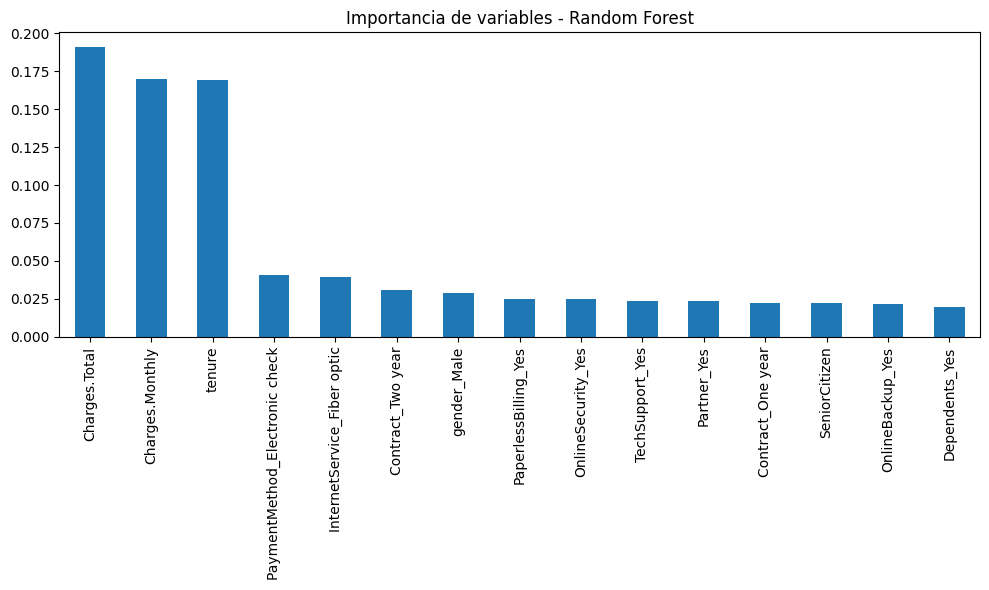

In [17]:
plt.figure(figsize=(10,6))
importances.sort_values(ascending=False).head(15).plot(kind="bar")
plt.title("Importancia de variables - Random Forest")
plt.tight_layout()
plt.show()

In [18]:
df.head()

,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


In [19]:
df_encoded.head()

,SeniorCitizen,tenure,Charges.Monthly,Charges.Total,Churn_Yes,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,9,65.6,593.30,False,False,True,True,True,False,False,False,False,False,False,False,True,False,False,False,True,False,True,False,False,True,False,True,False,False,True
1,0,9,59.9,542.40,False,True,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True
2,0,4,73.9,280.85,True,True,False,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,True,False
3,1,13,98.0,1237.85,True,True,True,False,True,False,False,True,False,False,False,False,True,False,True,False,False,False,True,False,True,False,False,True,False,True,False
4,1,3,83.9,267.40,True,False,True,False,True,False,False,True,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,True,False,False,True


In [20]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def metrics(y_true, y_pred, name):
    return {
        "Modelo": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision (Churn)": precision_score(y_true, y_pred),
        "Recall (Churn)": recall_score(y_true, y_pred),
        "F1 (Churn)": f1_score(y_true, y_pred)
    }

results = [
    metrics(y_test, y_pred_log, "Logistic Regression"),
    metrics(y_test, y_pred_knn, "KNN"),
    metrics(y_test, y_pred_rf, "Random Forest"),
    metrics(y_test, y_pred_svm, "SVM")
]

results_df = pd.DataFrame(results)
results_df

,Modelo,Accuracy,Precision (Churn),Recall (Churn),F1 (Churn)
0,Logistic Regression,0.803318,0.657328,0.543672,0.595122
1,KNN,0.757820,0.547170,0.516934,0.531622
2,Random Forest,0.784834,0.621868,0.486631,0.546000
3,SVM,0.797156,0.657957,0.493761,0.564155


In [21]:
importances = pd.Series(rf_clf.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(15)

,0
Charges.Total,0.191118
Charges.Monthly,0.170190
tenure,0.169279
PaymentMethod_Electronic check,0.040759
InternetService_Fiber optic,0.039438
Contract_Two year,0.030721
gender_Male,0.029116
PaperlessBilling_Yes,0.025096
OnlineSecurity_Yes,0.024912
TechSupport_Yes,0.023649


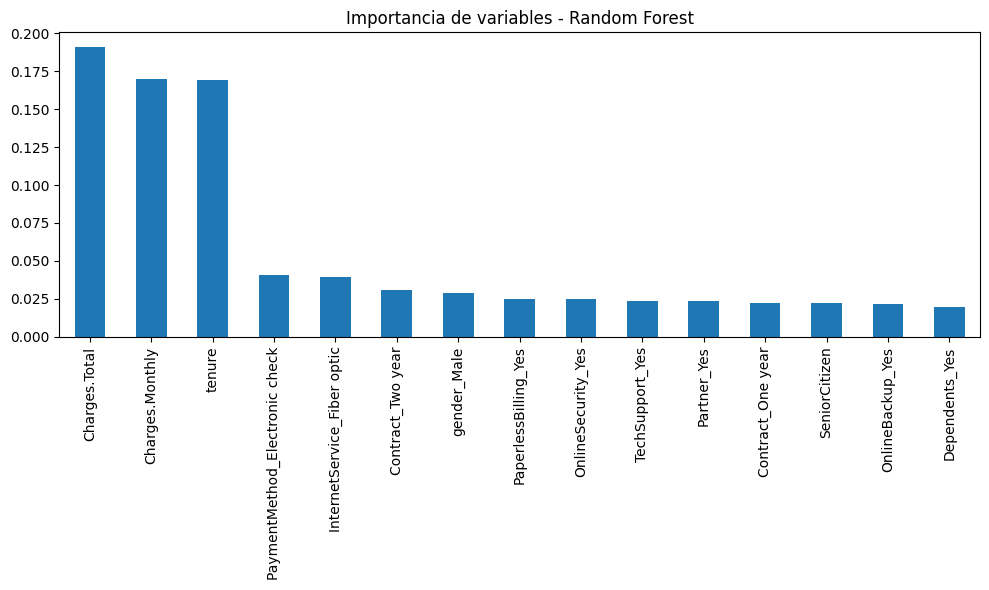

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
importances.sort_values(ascending=False).head(15).plot(kind="bar")
plt.title("Importancia de variables - Random Forest")
plt.tight_layout()
plt.show()